## Запрос 0 - Авторизация на MOEX (authenticated session)

Документация, которую использовали - https://www.moex.com/ru/documents/6523

MOEX ISS поддерживает basic-аутентификацию - это описано в документации на стр. 6.
Авторизация нужна чтобы получить доступ к данным без 15-минутной задержки (стр. 9).
Без авторизации исторические данные по итогам торгов доступны только с задержкой.

Документация (стр. 6): авторизация выполняется через специальную ссылку по HTTPS:
https://passport.moex.com/authenticate

При успешной аутентификации сервер возвращает cookie с именем MicexPassportCert, хранящей сертификат аутентификации. Cookie должен быть сохранён до указанного в нём времени жизни (expire) и отправляться при последующих запросах.

По запросу логина и пароля по ссылке - https://passport.moex.com/authenticate - выводит:

RrW2O1mWASiYz8rNKSQMIQMAAAB00oxu5WbGuB5RBlTA-5M73OAYZY-asMrKWmDtItOp3_c7Bux1y6UrKQDBAQTPi6deHp-t762LDGnz8YRoMfnRhXgFSt195Z3YN59xihOD34uIv8_lY-ASfMk5_VLRxGxLcMjvzEa_m0XFKKPo5A2

In [1]:
import requests

#авторизация на MOEX ISS через basic-аутентификацию
MOEX_LOGIN = 'orlovapolya0211@gmail.com' #логин от moex.com
MOEX_PASSWORD = 'E!3UStXK#wAwLgh'  #пароль от moex.com

session = requests.Session()
avtoriz_otvet = session.get(
    'https://passport.moex.com/authenticate',
    auth=(MOEX_LOGIN, MOEX_PASSWORD))

if avtoriz_otvet.status_code == 200:
    print('Авторизация успешна')
    print(f'Cookie получен: {"MicexPassportCert" in session.cookies}')
else:
    print(f'Ошибка авторизации: {avtoriz_otvet.status_code}')

Авторизация успешна
Cookie получен: True


MOEX ISS API - открытый, ключи не нужны, все запросы доступны без регистрации через обычный requests.get().
Но по условию проекта мы добавили авторизацию как усложнение.

Теперь все последующие запросы мы будем делать через session, а не через requests.get напрямую.

Тогда cookie передаётся автоматически и мы получаем данные без задержки.

# Logging - зачем добавили и как работает

Когда мы писали все 5 запросов везде использовали print(). Но потом вспомнили про условие в проекте про добавление logging.

Мы прочитали две статьи про logging - на Хабре и на Tproger - и поняли что logging нам будет полезен.

На Tproger написано: если у тебя нет логирования - ты не сможешь отследить, что привело к ошибке. В нашем случае - 7 компаний, каждая по несколько запросов к API. Если что-то упадёт - print() этого не сохранит, и мы запутаемся.

Из статьи на Хабре: "Использование print() вполне может оправдать себя при отладке маленьких программ. Но когда вы перейдёте к более крупным и сложным проектам - вам понадобится постоянный журнал, содержащий больше информации о поведении вашего кода".

Поэтому решили добавить logging в начало колаба.

**Что такое logging:**
Из статьи на Tproger: "модуль logging в Python - это набор функций и классов, которые позволяют регистрировать события, происходящие во время работы кода. Этот модуль входит в стандартную библиотеку, поэтому для его использования достаточно написать лишь одну строку import logging".

Мы выбрали уровень INFO - он пишет основные события (запрос отправлен, сколько строк получили), но не засоряет вывод лишними деталями.

**Основные параметры basicConfig()** (из статьи на Tproger):
- level - уровень логирования
- filename - файл куда направляем логи
- format - вид в котором сохраняем результат

**Конфигурационный файл:**

По условию проекта уровень логирования и включение/выключение должны настраиваться через отдельный файл, а не в коде. Поэтому все настройки мы вынесем в parametrs.txt - Python будет их читать оттуда перед запуском logging.

In [2]:
#cоздаём конфигурационный файл parametrs.txt
#параметры берём из статьи Tproger
#там написано - у basicConfig() три основных параметра - level, filename, format

parametrs_content = """enabled=true
level=INFO
filename=logs/logging_infa
format=%(asctime)s - %(levelname)s - %(lineno)d - %(message)s
"""
#enabled=true/false - включение/выключение logging без изменения кода
#level=INFO
#filename=logs/logging_infa - где хранятся наши логи
#Tproger: format=%(asctime)s - %(levelname)s - %(lineno)d - %(message)s
#убрали funcName потому что у нас нет функций
#%(asctime)s  - дата и время события
#%(levelname)s - уровень: INFO в нашем случае
#%(message)s  - само сообщение
#%(lineno)d - номер строки

with open('parametrs.txt', 'w') as filik:
    filik.write(parametrs_content)

print('создали parametrs.txt с такими параметрами:')
with open('parametrs.txt') as filik:
    print(filik.read())

создали parametrs.txt с такими параметрами:
enabled=true
level=INFO
filename=logs/logging_infa
format=%(asctime)s - %(levelname)s - %(lineno)d - %(message)s



In [3]:
!mkdir -p logs #создали папку, где будет файл с логами

In [4]:
import logging

#читаем наши настройки из parametrs.txt
with open('parametrs.txt') as filik:
    lines = filik.readlines()

enabled = lines[0].split('=')[1].strip()
level_str = lines[1].split('=')[1].strip()
filename = lines[2].split('=')[1].strip()
log_format = lines[3].split('=')[1].strip()

if enabled == 'true':

    #сбрасываем старые handlers
    #потому что иначе basicConfig игнорируется в Colab
    for handler in logging.root.handlers[:]:
        logging.root.removeHandler(handler)

    #filename - из parametrs.txt
    #из Хабра нашли, что записываем сообщения в файл
    #файл будет хранить данные после завершения программы

    #format - из parametrs.txt
    #Tproger: format с %(asctime)s %(levelname)s %(message)s

    #запись в файл
    #Tproger: 'logging.basicConfig() - основная функция для настройки logging'
    #уровень INFO - вывод данных о фрагментах кода, работающих так как ожидается
    logging.basicConfig(level=logging.INFO, filename=filename, format=log_format, filemode='a')
    #filemode='a' - логи добавляются в конец файла и не стираются при перезапуске

    logging.info('Подключаем logging и собираем данные с MOEX ISS API')
    print(f'Logging работает: уровень={level_str}, файл={filename}')

else:
    print('Logging не работает')

Logging работает: уровень=INFO, файл=logs/logging_infa


Запустили логгирование Теперь каждый запрос к API пишет в лог:
- что именно запрашиваем
- сколько строк получили
- итоговый результат или ошибку

Лог выводится в консоль и одновременно сохраняется в файл logs/logging_infa.
Чтобы выключить logging - меняем enabled=false в parametrs.txt, код не трогаем.


# Базовая инфа - Что? Откуда? И куда?

Для получения исторических котировок мы используем MOEX ISS API - официальный программный интерфейс Московской Биржи.

Путь к документации: сайт moex.com -> раздел API (https://www.moex.com/a2193) -> Руководство разработчика v1.4 -> оттуда нашли онлайн-справочник запросов: http://iss.moex.com/iss/reference/

Из документации (стр. 4) узнали, что запросы строятся по цепочке параметров:

/engines/(trade_engine_name)

/markets/(market_name)

/boards/(boardid)

/securities/{secid}

Из документации (стр. 8) узнали, что /candles - это рассчитанные данные для построения графиков (свечек).





# Подготовка к запросам

Итоговый URL первого запроса для Сбербанка:
http://iss.moex.com/iss/engines/stock/markets/shares/boards/TQBR/securities/SBER/candles.json

*Там же в документации (стр. 8) увидели что /candles принимает параметр interval - размер одной свечи. Значение interval=24 означает один торговый день. То есть каждая строка в ответе будет соответствовать одному торговому дню, что нам и нужно для анализа дневных котировок.

Тикер - это короткое буквенное обозначение акции на бирже.
Чтобы сделать запрос к API MOEX, нам нужно знать точный тикер каждой компании.
Мы нашли тикеры на официальном сайте Мосбиржи в списке ценных бумаг: https://www.moex.com/ru/listing/securities-list.aspx

Там можно найти любую компанию по названию и посмотреть её тикер.

In [5]:
import requests #сначала все запросы писали через requests.get() напрямую, потом переписали через session для логгирования
import pandas as pd

Импортируем две библиотеки:
- **requests** - для отправки HTTP-запросов к API биржи (для колаба без логгирования нужна была)
- **pandas** - для работы с таблицами. Превращаем неудобный JSON в удобный DataFrame

## Запрос 1 - Дневные свечи (candles)

**Цель:** получить историю дневных цен Сбербанка за период 2018-01-01 - 2025-12-31.

Это главные данные всего проекта. Без них невозможно посчитать нашу таргетную переменную - изменение цены акции через 24 часа после выхода новости.

Каждая строка в ответе = один торговый день.


In [6]:
#запрос 1: получаем дневные свечи СБЕРБАНК с MOEX (первые 500 строк)
response_SBER = session.get(
      'https://iss.moex.com/iss/engines/stock/markets/shares/boards/TQBR/securities/SBER/candles.json',
      params={
          'from': '2018-01-01',
          'till': '2025-12-31',
          'interval': 24})

data_SBER = response_SBER.json()

#извлекаем данные из json
columns_SBER = data_SBER['candles']['columns']
rows_SBER = data_SBER['candles']['data']

df_SBER = pd.DataFrame(rows_SBER, columns=columns_SBER)
df_SBER['ticker'] = 'SBER'

print(f'Count of rows: {len(df_SBER)}')
#считаем все строки - мало ли их много, а выводит только 500
df_SBER


Count of rows: 500


,open,close,high,low,value,volume,begin,end,ticker
0,226.88,231.90,232.70,226.35,7.965493e+09,34549620,2018-01-03 00:00:00,2018-01-03 23:59:59,SBER
1,232.13,238.80,239.50,231.00,1.263668e+10,53598520,2018-01-04 00:00:00,2018-01-04 23:59:59,SBER
2,238.89,238.60,239.95,236.70,7.522345e+09,31579190,2018-01-05 00:00:00,2018-01-05 23:59:59,SBER
3,239.03,240.40,243.76,239.01,1.283838e+10,53172330,2018-01-09 00:00:00,2018-01-09 23:59:59,SBER
4,240.40,237.76,241.25,237.06,9.385277e+09,39371720,2018-01-10 00:00:00,2018-01-10 23:59:59,SBER
...,...,...,...,...,...,...,...,...,...
495,242.48,241.45,242.48,240.13,6.186561e+09,25624180,2019-12-16 00:00:00,2019-12-16 23:59:59,SBER
496,241.80,241.60,242.96,241.00,8.187208e+09,33841520,2019-12-17 00:00:00,2019-12-17 23:59:59,SBER
497,241.30,246.20,246.25,240.36,1.360110e+10,55765490,2019-12-18 00:00:00,2019-12-18 23:59:59,SBER
498,246.20,244.00,248.40,243.10,1.472618e+10,59951760,2019-12-19 00:00:00,2019-12-19 23:59:59,SBER


**Результат:** Count of rows: 500

Таблица содержит 9 колонок:
- open - цена акции Сбербанка в начале торгового дня (рублей за акцию)
- close - цена в конце торгового дня
- high - максимальная цена за день
- low - минимальная цена за день
- value - суммарный оборот за день в рублях (сколько рублей прошло через все сделки)
- volume - количество акций сменивших владельца за день
- begin - дата и время начала торгового дня
- end - дата и время конца торгового дня
- ticker - тикер бумаги (добавили сами, чтобы потом объединить все 9 компаний)


Также из документации (стр. 11) узнали что сервер возвращает данные порциями. Чтобы выгрузить полный объём данных, нужно последовательно делать запросы, увеличивая параметр start на значение pagesize, пока не получим пустой блок данных.



In [7]:
logging.info('Запрос 1: проверяем есть ли данные после 500 строки (start=500)')
#проверяем есть ли данные ниже 500 строки
response_SBER = session.get(
      'https://iss.moex.com/iss/engines/stock/markets/shares/boards/TQBR/securities/SBER/candles.json',
      params={
          'from': '2018-01-01',
          'till': '2025-12-31',
          'interval': 24,
          'start': 500
      })

data_SBER = response_SBER.json()
print(f"Count of rows after 500 rows: {len(data_SBER['candles']['data'])}")
#строк много - выводим оставшиеся


Count of rows after 500 rows: 500


**Результат:** Count of rows after 500 rows: 500

HOOORRAY!!))

Ну вот видите?)

Данные не закончились на 500-й строке. Получили ещё 500 строк - это оставшиеся торговые дни, которые не влезли в первый запрос.

Теперь будем проверять, пока нам не выведет 0 значений.

In [8]:
columns_SBERnew = data_SBER['candles']['columns']
rows_SBERnew = data_SBER['candles']['data']

df_SBERnew = pd.DataFrame(rows_SBERnew, columns=columns_SBERnew)
df_SBERnew['ticker'] = 'SBER'

print(f'Count of rows after 500 rows: {len(df_SBERnew)}')

#проверяем есть ли данные ниже 1000 строки
logging.info('Запрос 1: проверяем есть ли данные после 1000 строки (start=1000)')
response_SBER2 = session.get(
      'https://iss.moex.com/iss/engines/stock/markets/shares/boards/TQBR/securities/SBER/candles.json',
      params={
          'from': '2018-01-01',
          'till': '2025-12-31',
          'interval': 24,
          'start': 1000
      })

data_SBER2 = response_SBER2.json()
columns_SBERnew2 = data_SBER2['candles']['columns']
rows_SBERnew2 = data_SBER2['candles']['data']

df_SBERnew2 = pd.DataFrame(rows_SBERnew2, columns=columns_SBERnew2)
df_SBERnew2['ticker'] = 'SBER'

print(f'Count of rows after 1000 rows: {len(df_SBERnew2)}')

#проверяем есть ли данные ниже 1500 строки
logging.info('Запрос 1: проверяем есть ли данные после 1500 строки (start=1500)')
response_SBER3 = session.get(
      'https://iss.moex.com/iss/engines/stock/markets/shares/boards/TQBR/securities/SBER/candles.json',
      params={
          'from': '2018-01-01',
          'till': '2025-12-31',
          'interval': 24,
          'start': 1500
      })

data_SBER3 = response_SBER3.json()
columns_SBERnew3 = data_SBER3['candles']['columns']
rows_SBERnew3 = data_SBER3['candles']['data']

df_SBERnew3 = pd.DataFrame(rows_SBERnew3, columns=columns_SBERnew3)
df_SBERnew3['ticker'] = 'SBER'

print(f'Count of rows after 1500 rows: {len(df_SBERnew3)}')



Count of rows after 500 rows: 500
Count of rows after 1000 rows: 500
Count of rows after 1500 rows: 500


In [9]:
#проверяем есть ли данные ниже 2000 строки

logging.info('Запрос 1: проверяем есть ли данные после 2000 строки (start=2000)')
response_SBER4 = session.get(
      'https://iss.moex.com/iss/engines/stock/markets/shares/boards/TQBR/securities/SBER/candles.json',
      params={
          'from': '2018-01-01',
          'till': '2025-12-31',
          'interval': 24,
          'start': 2000
      })

data_SBER4 = response_SBER4.json()
columns_SBERnew4 = data_SBER4['candles']['columns']
rows_SBERnew4 = data_SBER4['candles']['data']

df_SBERnew4 = pd.DataFrame(rows_SBERnew4, columns=columns_SBERnew4)
df_SBERnew4['ticker'] = 'SBER'

print(f'Count of rows after 2000 rows: {len(df_SBERnew4)}')

Count of rows after 2000 rows: 73


In [10]:
#проверяем есть ли данные ниже 2073 строки
logging.info('Запрос 1: проверяем есть ли данные после 2073 строки (start=2073)')
response_SBER5 = session.get(
      'https://iss.moex.com/iss/engines/stock/markets/shares/boards/TQBR/securities/SBER/candles.json',
      params={
          'from': '2018-01-01',
          'till': '2025-12-31',
          'interval': 24,
          'start': 2073
      })

data_SBER5 = response_SBER5.json()
columns_SBERnew5 = data_SBER5['candles']['columns']
rows_SBERnew5 = data_SBER5['candles']['data']

df_SBERnew5 = pd.DataFrame(rows_SBERnew5, columns=columns_SBERnew5)
df_SBERnew5['ticker'] = 'SBER'

print(f'Count of rows after 2073 rows: {len(df_SBERnew5)}')

Count of rows after 2073 rows: 0


In [11]:
#больше данных нет, поэтому обьединяем датафреймы в один
df_SBERcandles = pd.concat([df_SBER, df_SBERnew, df_SBERnew2, df_SBERnew3, df_SBERnew4], ignore_index=True)
print(f'Total rows: {len(df_SBERcandles)}')

logging.info(f'Запрос 1: итого после склейки пяти датафреймов - {len(df_SBERcandles)} строк')
df_SBERcandles

Total rows: 2073


,open,close,high,low,value,volume,begin,end,ticker
0,226.88,231.90,232.70,226.35,7.965493e+09,34549620,2018-01-03 00:00:00,2018-01-03 23:59:59,SBER
1,232.13,238.80,239.50,231.00,1.263668e+10,53598520,2018-01-04 00:00:00,2018-01-04 23:59:59,SBER
2,238.89,238.60,239.95,236.70,7.522345e+09,31579190,2018-01-05 00:00:00,2018-01-05 23:59:59,SBER
3,239.03,240.40,243.76,239.01,1.283838e+10,53172330,2018-01-09 00:00:00,2018-01-09 23:59:59,SBER
4,240.40,237.76,241.25,237.06,9.385277e+09,39371720,2018-01-10 00:00:00,2018-01-10 23:59:59,SBER
...,...,...,...,...,...,...,...,...,...
2068,300.26,302.51,302.60,300.02,7.471306e+09,24760307,2025-12-26 00:00:00,2025-12-26 23:59:58,SBER
2069,302.66,302.63,303.20,302.51,5.536735e+08,1827803,2025-12-27 00:00:00,2025-12-27 23:59:57,SBER
2070,302.60,302.55,302.83,301.37,9.408030e+08,3113900,2025-12-28 00:00:00,2025-12-28 23:59:57,SBER
2071,303.00,299.70,306.20,298.50,1.568448e+10,51927078,2025-12-29 00:00:00,2025-12-29 23:59:59,SBER


Hooray!

Пустой ответ подтверждает, что мы выгрузили абсолютно все данные. После 2073 строки данных нет. Значит итоговый датафрейм df_SBERcandles содержит полную историю дневных котировок Сбербанка за весь нужный период без пропусков.

**Результат:**

Total rows: 2073


Склеили пять кусков через pd.concat с параметром ignore_index=True - пересчитаем индексы строк заново от 0, иначе в итоговой таблице было бы пять наборов индексов, что вызвало бы у нас путаницу и отсутствие hoorray(.

Итого получили **2073 строк** - это все торговые дни Сбербанка за период с 01.01.2018 по 31.12.2025.



## Запрос 2 - Информация о бумаге (security info)

**Цель:** получить полную информацию по акциям Сбербанка: официальное название компании, международный код бумаги (ISIN), номинальная стоимость акции и уровень листинга.

Эти данные нужны нам для двух вещей:
1. Красиво описать датасет в README - чтобы было понятно с какими именно бумагами работаем
2. Добавить уровень листинга как признак в EDA - бумаги первого уровня листинга торгуются активнее и имеют более строгие требования к раскрытию информации

В онлайн-справочнике запросов ISS API: https://iss.moex.com/iss/reference/.

Там есть отдельный раздел /securities/[security] - https://iss.moex.com/iss/reference/193 - запрос по конкретному инструменту.

Вместо [security] вставляем тикер компании.
https://iss.moex.com/iss/securities/SBER.json

In [12]:
#запрос 2: получаем статические характеристики бумаги СБЕРБАНК
#нам возвращается: полное название, ISIN, номинал, уровень листинга, тип бумаги
response_SBER_infa = session.get(
    'https://iss.moex.com/iss/securities/SBER.json')

data_SBER_infa = response_SBER_infa.json()

#раздел 'description' содержит характеристики в виде строк name/value
columns_SBER_infa = data_SBER_infa['description']['columns']
rows_SBER_infa = data_SBER_infa['description']['data']

df_SBER_infa = pd.DataFrame(rows_SBER_infa, columns=columns_SBER_infa)
df_SBER_infa['ticker'] = 'SBER'

print(f'Count of rows: {len(df_SBER_infa)}')
df_SBER_infa

Count of rows: 27


,name,title,value,type,sort_order,is_hidden,precision,ticker
0,SECID,Код ценной бумаги,SBER,string,1,0,NaN,SBER
1,ISSUENAME,Наименование ценной бумаги,Акции обыкновенные,string,2,0,NaN,SBER
2,NAME,Полное наименование,Сбербанк России ПАО ао,string,3,0,NaN,SBER
3,SHORTNAME,Краткое наименование,Сбербанк,string,4,0,NaN,SBER
4,ISIN,ISIN код,RU0009029540,string,5,0,NaN,SBER
5,REGNUMBER,Номер государственной регистрации,10301481B,string,6,0,NaN,SBER
6,ISSUESIZE,Объем выпуска,21586948000,number,7,0,0.0,SBER
7,FACEVALUE,Номинальная стоимость,3,number,8,0,2.0,SBER
8,FACEUNIT,Валюта номинала,SUR,string,9,0,NaN,SBER
9,ISSUEDATE,Дата начала торгов,2007-07-20,date,10,0,NaN,SBER


**Результат:** Count of rows: 27

Получили 27 строк.

Каждая строка это одна характеристика бумаги.

Каждая характеристика на отдельной строке.

Это неудобно для анализа, поэтому в следующей ячейке мы преобразуем это формат, где одна строка на компанию, каждая характеристика отдельная колонка.

In [13]:
#преобразуем в удобный формат: одна строка - один тикер
#разворачиваем колонку 'name' в отдельные колонки через pivot
df_SBER_infa_best = df_SBER_infa.set_index('name')['value'].to_frame().T
df_SBER_infa_best['ticker'] = 'SBER'
df_SBER_infa_best = df_SBER_infa_best.reset_index()

print(f'Полное название: {df_SBER_infa_best["NAME"].values[0]}')
print(f'ISIN: {df_SBER_infa_best["ISIN"].values[0]}')
print(f'Уровень листинга: {df_SBER_infa_best["LISTLEVEL"].values[0]}')

logging.info(f'Запрос 2: ISIN={df_SBER_infa_best["ISIN"].values[0]}, листинг={df_SBER_infa_best["LISTLEVEL"].values[0]}')

df_SBER_infa_best

Полное название: Сбербанк России ПАО ао
ISIN: RU0009029540
Уровень листинга: 1


name,index,SECID,ISSUENAME,NAME,SHORTNAME,ISIN,REGNUMBER,ISSUESIZE,FACEVALUE,FACEUNIT,...,MORNINGSESSION,EVENINGSESSION,WEEKENDSESSION,REGISTRY_DATE,TYPENAME,GROUP,TYPE,GROUPNAME,EMITTER_ID,ticker
0,value,SBER,Акции обыкновенные,Сбербанк России ПАО ао,Сбербанк,RU0009029540,10301481B,21586948000,3,SUR,...,1,1,1,2007-07-11,Акция обыкновенная,stock_shares,common_share,Акции,484,SBER


**Результат:**

Полное название: Сбербанк России ПАО ао
ISIN: RU0009029540
Уровень листинга: 1


Теперь это одна строка с колонками NAME, ISIN, LISTLEVEL и тд.

Что значат выводы:
- **NAME = "Сбербанк России ПАО ао"** - официальное юридическое название компании.
- **ISIN = RU0009029540** - международный идентификационный номер ценной бумаги.
- **LISTLEVEL = 1** - первый  уровень листинга на Мосбирже. Это значит, что Сбербанк прошёл самые строгие требования биржи по прозрачности и раскрытию информации.

**Итог запроса 2:** получили официальную информацию по бумаге.

Hooray!))

## Запрос 3 - История дивидендов (dividends)

**Цель:** получить все даты дивидендных выплат Сбербанка за период проекта.

Зачем нам это нужно: когда компания выплачивает дивиденды, цена акции резко падает примерно на размер дивиденда.

Если мы не пометим эти дни, то можем ошибочно решить в EDA, что резкое падение цены вызвано негативной новостью - хотя на самом деле это просто плановая выплата. Это могло бы нам помешать.

Эндпоинт для получения дивидендов не указан в официальном справочнике. Пришлось искать в интернете. Нашли в обсуждении на Хабре (https://habr.com/ru/articles/486716/comments/#comment_21279702), там разработчики упоминали что URL строится по той же логике цепочки что и остальные запросы ISS, просто добавляется /dividends после тикера:
https://iss.moex.com/iss/securities/SBER/dividends.json

Проверили напрямую в браузере - запрос вернул данные.

Вот это настоящий Hooray!)

In [14]:
logging.info('Запрос 3: загружаем историю дивидендов SBER')
#запрос 3: получаем историю дивидендных выплат СБЕРБАНК
#дивиденды влияют на котировки примерно на размер дивиденда
SBER_diva = session.get(
    'https://iss.moex.com/iss/securities/SBER/dividends.json')

SBER_diva_infa = SBER_diva.json()

#извлекаем данные из json
columns_SBER_diva = SBER_diva_infa['dividends']['columns']
rows_SBER_diva = SBER_diva_infa['dividends']['data']

df_SBER_diva = pd.DataFrame(rows_SBER_diva, columns=columns_SBER_diva)
df_SBER_diva['ticker'] = 'SBER'

print(f'Count of rows: {len(df_SBER_diva)}')

logging.info(f'Запрос 3: получено {len(df_SBER_diva)} дивидендных выплат')
df_SBER_diva

Count of rows: 6


,secid,isin,registryclosedate,value,currencyid,ticker
0,SBER,RU0009029540,2019-06-13,16.00,RUB,SBER
1,SBER,RU0009029540,2020-10-05,18.70,RUB,SBER
2,SBER,RU0009029540,2021-05-12,18.70,RUB,SBER
3,SBER,RU0009029540,2023-05-11,25.00,RUB,SBER
4,SBER,RU0009029540,2024-07-11,33.30,RUB,SBER
5,SBER,RU0009029540,2025-07-18,34.84,RUB,SBER


**Результат:** Count of rows: 6

API вернул 6 выплат дивидентов за все годы существования на бирже. Таблица содержит колонки:

- **registryclosedate** - дата закрытия реестра.
- **value** - размер дивиденда на одну акцию в рублях.

Нам нужны только выплаты за наш период 2018–2025, поэтому сейчас будет фильтровать.

In [15]:
#фильтруем дивиденды по диапазону дат проекта 2018-01-01 - 2025-12-31
df_SBER_diva['registryclosedate'] = pd.to_datetime(df_SBER_diva['registryclosedate'])
df_SBER_diva_srok = df_SBER_diva[
    (df_SBER_diva['registryclosedate'] >= '2018-01-01') &
    (df_SBER_diva['registryclosedate'] <= '2025-12-31')].reset_index()

print(f'Все дивиденты за 2018-01-01 - 2025-12-31: {len(df_SBER_diva_srok)}')

logging.info(f'Запрос 2: ISIN={df_SBER_infa_best["ISIN"].values[0]}, листинг={df_SBER_infa_best["LISTLEVEL"].values[0]}')
df_SBER_diva_srok

Все дивиденты за 2018-01-01 - 2025-12-31: 6


,index,secid,isin,registryclosedate,value,currencyid,ticker
0,0,SBER,RU0009029540,2019-06-13,16.00,RUB,SBER
1,1,SBER,RU0009029540,2020-10-05,18.70,RUB,SBER
2,2,SBER,RU0009029540,2021-05-12,18.70,RUB,SBER
3,3,SBER,RU0009029540,2023-05-11,25.00,RUB,SBER
4,4,SBER,RU0009029540,2024-07-11,33.30,RUB,SBER
5,5,SBER,RU0009029540,2025-07-18,34.84,RUB,SBER


**Результат:** Все дивиденты за 2018-01-01 - 2025-12-31: 6


Почему конвертировали дату через pd.to_datetime: без этого Python сравнивал бы строки а не даты. Строковое сравнение работает по алфавиту и даёт неверные результаты для дат в формате YYYY-MM-DD.

**Итог запроса 3:** знаем точные даты дивидендных выплат. В EDA пометим эти дни флагом is_dividend_day=1.

## Запрос 4 - Текущие рыночные данные (market data)

Запрос 4 получает текущие торговые данные по Сберу - последнюю цену, объём торгов за день, количество сделок и капитализацию компании. Всё это показывает насколько активно торгуется акция прямо сейчас.


Эти данные характеризуют **ликвидность** бумаги - насколько активно она торгуется. В EDA мы будем использовать их чтобы показать: более ликвидные бумаги быстрее и точнее реагируют на новости, потому что больше участников рынка мгновенно перекладываются после публикации статьи.

Нашли в документации (https://iss.moex.com/iss/reference/353)

In [16]:
logging.info('Запрос 4: загружаем текущие рыночные данные SBER')
#запрос 4: получаем текущие торговые данные СБЕРБАНК
response_SBER_markdata = session.get(
    'https://iss.moex.com/iss/engines/stock/markets/shares/boards/TQBR/securities/SBER.json')

data_SBER_markdata = response_SBER_markdata.json()


#раздел 'marketdata' содержит торговые данные текущей/последней сессии
columns_SBER_markdata = data_SBER_markdata['marketdata']['columns']
rows_SBER_markdata = data_SBER_markdata['marketdata']['data']

df_SBER_markdata = pd.DataFrame(rows_SBER_markdata, columns=columns_SBER_markdata)
df_SBER_markdata['ticker'] = 'SBER'

print(f'Count of rows: {len(df_SBER_markdata)}')

logging.info(f'Запрос 4: получено {len(df_SBER_markdata)} строк market data')
df_SBER_markdata

Count of rows: 1


,SECID,BOARDID,BID,BIDDEPTH,OFFER,OFFERDEPTH,SPREAD,BIDDEPTHT,OFFERDEPTHT,OPEN,...,SYSTIME,CLOSINGAUCTIONPRICE,CLOSINGAUCTIONVOLUME,ISSUECAPITALIZATION,ISSUECAPITALIZATION_UPDATETIME,ETFSETTLECURRENCY,VALTODAY_RUR,TRADINGSESSION,TRENDISSUECAPITALIZATION,ticker
0,SBER,TQBR,None,None,None,None,0,0,0,321,...,2026-03-20 23:50:42,320.46,152223,6911277271680,23:49:57,None,6984138254,None,0,SBER


**Результат:** Count of rows: 1

Одна строка - потому что это текущие торговые данные. Но колонок очень много. API возвращает абсолютно всё что знает о торговле этой бумагой прямо сейчас.

Большинство колонок нам не нужны - это технические поля биржи вроде кодов режимов торгов, флагов состояния и прочего. В следующей ячейке оставим только то что важно для нашего будущего анализа.

In [17]:
#оставляем только нужные колонки из market data
#используем фильтрацию через список - так код не упадёт если какой-то колонки нет в ответе
markdata_cols = ['ticker', 'LAST', 'LASTTOPREVPRICE', 'BID', 'OFFER',
            'OPEN', 'HIGH', 'LOW', 'WAPRICE', 'NUMTRADES',
            'VOLTODAY', 'VALTODAY', 'ISSUECAPITALIZATION', 'UPDATETIME']
markdata_cols = [col for col in markdata_cols if col in df_SBER_markdata.columns]

df_SBER_markdata_best = df_SBER_markdata[markdata_cols].copy()

#выводим ключевые показатели
print(f'Последняя цена SBER: {df_SBER_markdata_best["LAST"].values[0]}')
print(f'Изменение к пред. закрытию: {df_SBER_markdata_best["LASTTOPREVPRICE"].values[0]}')
print(f'Капитализация: {df_SBER_markdata_best["ISSUECAPITALIZATION"].values[0]}')

logging.info(f'Запрос 4: последняя цена SBER={df_SBER_markdata_best["LAST"].values[0]}')

df_SBER_markdata_best

Последняя цена SBER: 320.16
Изменение к пред. закрытию: -0.19
Капитализация: 6911277271680


,ticker,LAST,LASTTOPREVPRICE,BID,OFFER,OPEN,HIGH,LOW,WAPRICE,NUMTRADES,VOLTODAY,VALTODAY,ISSUECAPITALIZATION,UPDATETIME
0,SBER,320.16,-0.19,None,None,321,322,319.51,321,106329,21758167,6984138254,6911277271680,23:50:21


**Результат:** (тут данные могут изменяться при каждом запуске)

Последняя цена SBER: 320.89
Изменение к пред. закрытию: -0.15
Капитализация: 6908039229480


Что означают колонки которые мы оставили:
- **LAST** - последняя цена сделки (рублей за акцию)
- **LASTTOPREVPRICE** - изменение в % к цене закрытия предыдущего дня
- **BID / OFFER** - лучшая цена покупки и продажи прямо сейчас. Разница между ними называется спредом - чем он уже, тем ликвиднее бумага
- **WAPRICE** - средневзвешенная цена за весь день (учитывает объём каждой сделки)
- **NUMTRADES** - количество сделок за торговый день. У Сбербанка это десятки тысяч - одна из самых торгуемых бумаг на бирже
- **VOLTODAY / VALTODAY** - объём в акциях и оборот в рублях за сегодня
- **ISSUECAPITALIZATION** - рыночная капитализация в рублях.

**Итог запроса 4:** получили характеристику ликвидности Сбербанка на текущий момент.

## Запрос 5 - Индексная принадлежность (indices)

**Цель:** узнать в какие биржевые индексы входит Сбербанк.

Индексные бумаги - особая категория. Когда акция входит в IMOEX (Индекс МосБиржи), за ней автоматически следят индексные фонды (ETF) и управляющие компании. Это означает что при выходе важной новости реагируют не только частные инвесторы, но и алгоритмы фондов.

В EDA мы сравним: одинаково ли сильно реагируют на новости индексные бумаги и менее крупные компании из нашего списка.

Нашли в документации - https://iss.moex.com/iss/reference/199

In [18]:
logging.info('Запрос 5: загружаем индексы SBER')
#запрос 5: получаем список биржевых индексов в которые входит СБЕРБАНК
response_SBER_idishka = session.get(
    'https://iss.moex.com/iss/securities/SBER/indices.json')

data_SBER_idishka = response_SBER_idishka.json()

#извлекаем данные из json
columns_SBER_idishka = data_SBER_idishka['indices']['columns']
rows_SBER_idishka = data_SBER_idishka['indices']['data']

df_SBER_idishka = pd.DataFrame(rows_SBER_idishka, columns=columns_SBER_idishka)
df_SBER_idishka['ticker'] = 'SBER'

print(f'Count of rows: {len(df_SBER_idishka)}')

logging.info(f'Запрос 5: SBER входит в {len(df_SBER_idishka)} индексов')

df_SBER_idishka

Count of rows: 19


,SECID,SHORTNAME,FROM,TILL,CURRENTVALUE,LASTCHANGEPRC,LASTCHANGE,ticker
0,EPSI,Субиндекс акций,2011-11-21,2026-03-20,1663.37,-0.12,-2.01,SBER
1,ESGI,Индекс МосБиржи Рейтинги УР,2026-02-16,2026-03-20,992.11,0.33,3.24,SBER
2,IMOEXCNY,Индекс МосБиржи в юанях,2024-09-24,2026-03-20,1098.66,3.61,38.28,SBER
3,IMOEXW,IMOEXW,2023-01-16,2026-03-20,2877.93,-0.13,-3.65,SBER
4,MESG,Индекс МосБиржи-RAEX ESG,2023-12-22,2026-03-20,982.21,-0.26,-2.54,SBER
5,MOEXBC,Индекс голубых фишек,2010-01-14,2026-03-20,19031.78,-0.14,-25.78,SBER
6,MRRT,Индекс MRRT,2020-09-21,2026-03-20,2333.10,-0.12,-2.70,SBER
7,MRSV,Индекс MRSV,2020-09-21,2026-03-20,2170.79,-0.14,-3.07,SBER
8,MRSVR,Индекс МосБиржи-РСПП MRSV RU Co,2021-03-25,2026-03-20,2234.29,-0.14,-3.16,SBER
9,RTSfn,Индекс РТС финансов,2009-09-30,2026-03-20,202.50,1.30,2.60,SBER


**Результат:** Count of rows: 19


Важные колонки:
- **SECID** - код индекса
- **FROM / TILL** - период с которого по который бумага входит в индекс
- **CURRENTVALUE** - текущее значение самого индекса

In [19]:
#проверяем входит ли SBER в IMOEX (главный российский фондовый индекс)
if len(df_SBER_idishka) > 0:
    imoex_check = df_SBER_idishka[df_SBER_idishka['SECID'] == 'IMOEX']
    print(f'SBER входит в IMOEX: {len(imoex_check) > 0}')
else:
    print('SBER не входит ни в один индекс MOEX')
logging.info(f'Запрос 5 завершили - все данные по SBER собраны')


SBER входит в IMOEX: True


**Результат:**

SBER входит в IMOEX: True


Сбербанк входит в IMOEX - это подтверждает что он является влиятельной компанией российского рынка.

**Итог запроса 5:** Сбербанк входит в 19 индексов включая главный IMOEX. В EDA это будет важным признаком при анализе силы реакции на новости.





## Итог всего ноутбука

За 5 запросов к MOEX ISS API мы собрали полный набор данных по Сбербанку:


1. Candles - 2073 торговых дня с ценами открытия/закрытия/объёмом
2. Security info - информация по бумаге: название, ISIN, уровень листинга
3. Dividends - 6 дивидендных отсечек за 2018–2025 с суммами выплат
4. Market data - текущая инфа ликвидности: спред, капитализация, сделки
5. Indices - входит в 19 индексов включая IMOEX

# **HOORAY!!!!**

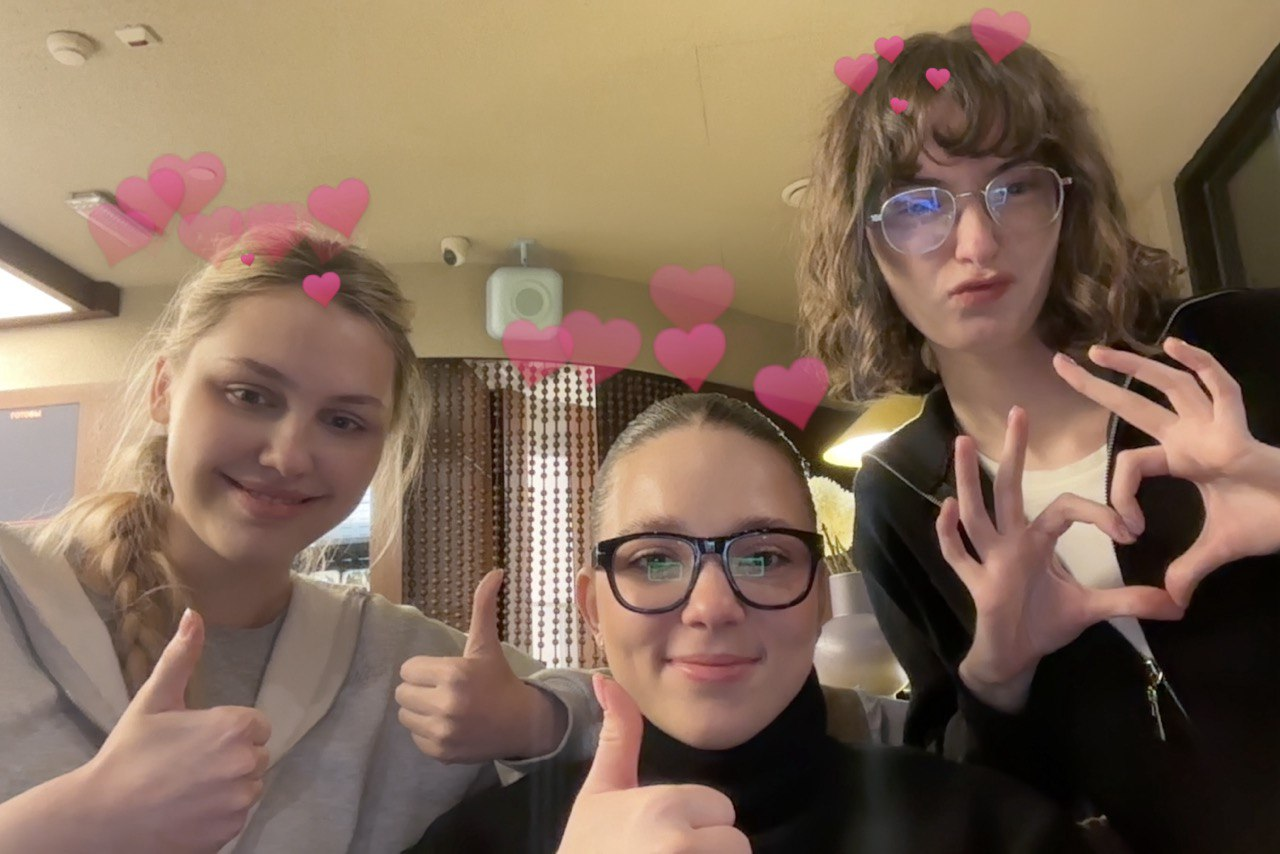